In [167]:
#Librerias
import kagglehub
import os

#Para entrenar el modelo
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


#MLFlow
import mlflow

from mlflow.models.signature import infer_signature

**Paso 1: Carga y describe el dataset:**

Importa los datos en un notebook.
Describe su estructura (número de registros, variables, tipos y significado).

In [168]:
# Descarga la carpeta completa del dataset
path = kagglehub.dataset_download("mnassrib/telecom-churn-datasets")

# 1. Carga el archivo directamente con pandas
df = pd.read_csv(os.path.join(path, "churn-bigml-80.csv"))
print(df.head())


  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

In [169]:
# 2. Dimensiones del dataset
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas\n")

# 3. Estructura general, tipos de datos y valores no nulos
print("=== Estructura y Tipos de Datos ===")
df.info()

# 4. Vista previa de los primeros registros
print("\n=== Primeros 5 registros ===")
display(df.head())

# 5. Resumen descriptivo de variables cuantitativas
print("\n=== Estadísticas descriptivas (Numéricas) ===")
display(df.describe().T)

# 6. Resumen de variables categóricas / booleanas
print("\n=== Estadísticas descriptivas (Categóricas) ===")
display(df.describe(include=["object", "bool"]).T)

Dimensiones: 2666 filas × 20 columnas

=== Estructura y Tipos de Datos ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls 

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False



=== Estadísticas descriptivas (Numéricas) ===


,count,mean,std,min,25%,50%,75%,max
Account length,2666.0,100.620405,39.563974,1.00,73.0000,100.00,127.000,243.00
Area code,2666.0,437.438860,42.521018,408.00,408.0000,415.00,510.000,510.00
Number vmail messages,2666.0,8.021755,13.612277,0.00,0.0000,0.00,19.000,50.00
Total day minutes,2666.0,179.481620,54.210350,0.00,143.4000,179.95,215.900,350.80
Total day calls,2666.0,100.310203,19.988162,0.00,87.0000,101.00,114.000,160.00
Total day charge,2666.0,30.512404,9.215733,0.00,24.3800,30.59,36.700,59.64
Total eve minutes,2666.0,200.386159,50.951515,0.00,165.3000,200.90,235.100,363.70
Total eve calls,2666.0,100.023631,20.161445,0.00,87.0000,100.00,114.000,170.00
Total eve charge,2666.0,17.033072,4.330864,0.00,14.0500,17.08,19.980,30.91
Total night minutes,2666.0,201.168942,50.780323,43.70,166.9250,201.15,236.475,395.00



=== Estadísticas descriptivas (Categóricas) ===


,count,unique,top,freq
State,2666,51,WV,88
International plan,2666,2,No,2396
Voice mail plan,2666,2,No,1933
Churn,2666,2,False,2278


In [170]:
data = [
    ["Account length", "integer", "Antigüedad de la cuenta (en días/meses)", "Feature"],
    ["Area code", "integer", "Código de área telefónico", "Feature"],
    ["International plan", "string", "¿Tiene contratado plan internacional? (Sí/No)", "Feature"],
    ["Voice mail plan", "string", "¿Tiene contratado plan de buzón de voz? (Sí/No)", "Feature"],
    ["Number vmail messages", "integer", "Cantidad de mensajes en el buzón de voz", "Feature"],
    ["Total day minutes", "double", "Minutos totales consumidos durante el día", "Feature"],
    ["Total day calls", "integer", "Número total de llamadas realizadas de día", "Feature"],
    ["Total day charge", "double", "Cobro total por llamadas diurnas", "Feature"],
    ["Total eve minutes", "double", "Minutos totales consumidos por la tarde/noche (evening)", "Feature"],
    ["Total eve calls", "integer", "Número total de llamadas por la tarde/noche", "Feature"],
    ["Total eve charge", "double", "Cobro total por llamadas de la tarde/noche", "Feature"],
    ["Total night minutes", "double", "Minutos totales consumidos en horario nocturno", "Feature"],
    ["Total night calls", "integer", "Número total de llamadas nocturnas", "Feature"],
    ["Total night charge", "double", "Cobro total por llamadas nocturnas", "Feature"],
    ["Total intl minutes", "double", "Minutos totales consumidos en llamadas internacionales", "Feature"],
    ["Total intl calls", "integer", "Número total de llamadas internacionales", "Feature"],
    ["Total intl charge", "double", "Cobro total por llamadas internacionales", "Feature"],
    ["Customer service calls", "integer", "Número de llamadas a atención a clientes", "Feature"],
    ["Churn", "string", "Cancelación o abandono del cliente", "Target"]
]

df_dict = pd.DataFrame(data, columns=["Variable", "Tipo de dato", "Significado en español", "Rol"])
display(df_dict)

,Variable,Tipo de dato,Significado en español,Rol
0,Account length,integer,Antigüedad de la cuenta (en días/meses),Feature
1,Area code,integer,Código de área telefónico,Feature
2,International plan,string,¿Tiene contratado plan internacional? (Sí/No),Feature
3,Voice mail plan,string,¿Tiene contratado plan de buzón de voz? (Sí/No),Feature
4,Number vmail messages,integer,Cantidad de mensajes en el buzón de voz,Feature
5,Total day minutes,double,Minutos totales consumidos durante el día,Feature
6,Total day calls,integer,Número total de llamadas realizadas de día,Feature
7,Total day charge,double,Cobro total por llamadas diurnas,Feature
8,Total eve minutes,double,Minutos totales consumidos por la tarde/noche ...,Feature
9,Total eve calls,integer,Número total de llamadas por la tarde/noche,Feature


**Paso 2: Realiza un análisis exploratorio (EDA):**

Genera estadísticas descriptivas y visualizaciones que te permitan entender la distribución de las variables y las relaciones entre ellas.

En total hay 16 columnas numéricas y 4 columnas cualitativas/categóricas.

Cantidad de registros duplicados: 0

Descripción estadística de las columnas numéricas:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Account length,2666.0,100.620405,39.563974,1.00,73.0000,100.00,127.000,243.00,0.079,-0.138
Area code,2666.0,437.438860,42.521018,408.00,408.0000,415.00,510.000,510.00,1.111,-0.742
Number vmail messages,2666.0,8.021755,13.612277,0.00,0.0000,0.00,19.000,50.00,1.272,-0.040
Total day minutes,2666.0,179.481620,54.210350,0.00,143.4000,179.95,215.900,350.80,-0.053,0.019
Total day calls,2666.0,100.310203,19.988162,0.00,87.0000,101.00,114.000,160.00,-0.128,0.290
Total day charge,2666.0,30.512404,9.215733,0.00,24.3800,30.59,36.700,59.64,-0.053,0.020
Total eve minutes,2666.0,200.386159,50.951515,0.00,165.3000,200.90,235.100,363.70,-0.013,-0.025
Total eve calls,2666.0,100.023631,20.161445,0.00,87.0000,100.00,114.000,170.00,-0.065,0.189
Total eve charge,2666.0,17.033072,4.330864,0.00,14.0500,17.08,19.980,30.91,-0.013,-0.026
Total night minutes,2666.0,201.168942,50.780323,43.70,166.9250,201.15,236.475,395.00,0.023,0.050



Descripción estadística de las columnas categóricas:


,count,unique,top,freq
State,2666,51,WV,88
International plan,2666,2,No,2396
Voice mail plan,2666,2,No,1933
Churn,2666,2,False,2278


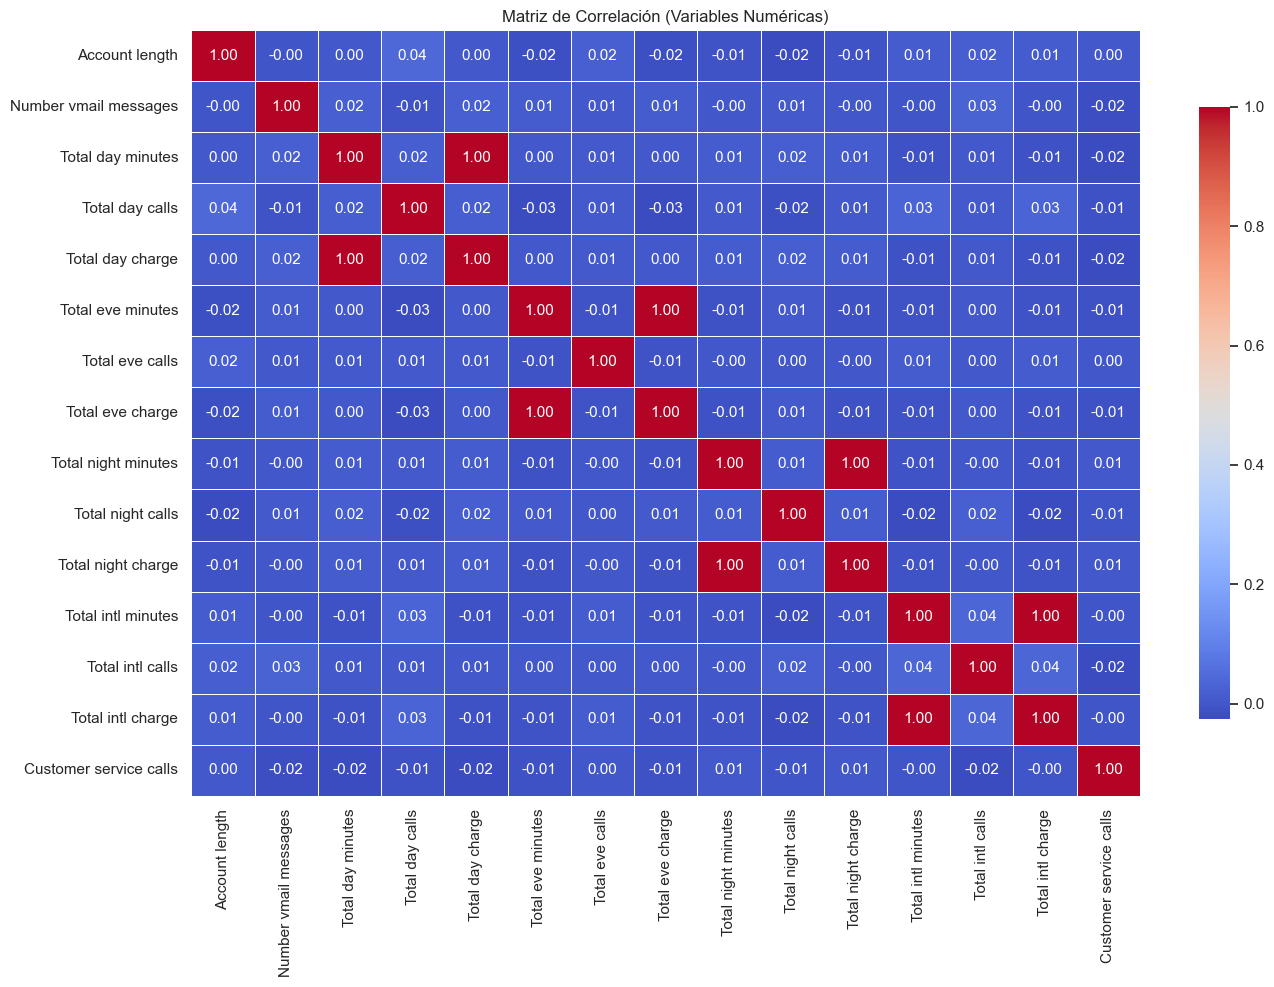


Pares de variables con correlación superior a 0.9 (Multicolinealidad crítica):
  • Total day minutes         y Total day charge          -> 1.0000
  • Total eve minutes         y Total eve charge          -> 1.0000
  • Total night minutes       y Total night charge        -> 1.0000
  • Total intl minutes        y Total intl charge         -> 1.0000


In [171]:
# =========================================================================
# 1. ENTENDIMIENTO DE TIPOS DE COLUMNAS Y DUPLICADOS
# =========================================================================

# Identificación de tipos de columnas (excluimos Churn del análisis numérico si fuera booleano)
num_cols = [
    c
    for c in df.select_dtypes(include=["number"]).columns
    if c not in ["Churn"]
]
text_cols = df.select_dtypes(
    include=["object", "string", "category", "bool"]
).columns.tolist()

print(
    f"En total hay {len(num_cols)} columnas numéricas y {len(text_cols)} columnas cualitativas/categóricas.\n"
)

# Valores duplicados
dupes = df.duplicated().sum()
print(f"Cantidad de registros duplicados: {dupes}\n")


# =========================================================================
# 2. ESTADÍSTICAS DESCRIPTIVAS (NUMÉRICAS Y CATEGÓRICAS)
# =========================================================================
# Numéricas con sesgo (skewness) y curtosis (kurtosis)
describe_num = df[num_cols].describe().T
describe_num["skewness"] = df[num_cols].skew().round(3)
describe_num["kurtosis"] = df[num_cols].kurtosis().round(3)
print("Descripción estadística de las columnas numéricas:")
display(describe_num)

# Columnas cualitativas/categóricas
describe_text = df[text_cols].describe().T
print("\nDescripción estadística de las columnas categóricas:")
display(describe_text)


# =========================================================================
# 3. MATRIZ DE CORRELACIÓN Y DETECCIÓN DE MULTICOLINEALIDAD (> 0.90)
# =========================================================================

# Selección de columnas numéricas (excluyendo Area code por ser nominal)
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(
    "Area code", errors="ignore"
)

# Matriz de correlación de Pearson
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Matriz de Correlación (Variables Numéricas)")
plt.tight_layout()
plt.show()



corr_matrix = df[num_cols].corr()

# Detección de pares con correlación > 0.90
mascara_pares = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
pares = corr_matrix.where(mascara_pares).stack()
pares_altos = pares[pares > 0.9].sort_values(ascending=False)

print("\n" + "=" * 50)
if not pares_altos.empty:
    print("Pares de variables con correlación superior a 0.9 (Multicolinealidad crítica):")
    for (v1, v2), valor in pares_altos.items():
        print(f"  • {v1:25} y {v2:25} -> {valor:.4f}")
else:
    print("No se encontraron pares con una correlación mayor a 0.9.")
print("=" * 50)

In [172]:
# Configuración estética general
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11

Frecuencia absoluta:
 Churn
False    2278
True      388
Name: count, dtype: int64

Porcentaje (%):
 Churn
False    85.45
True     14.55
Name: proportion, dtype: float64


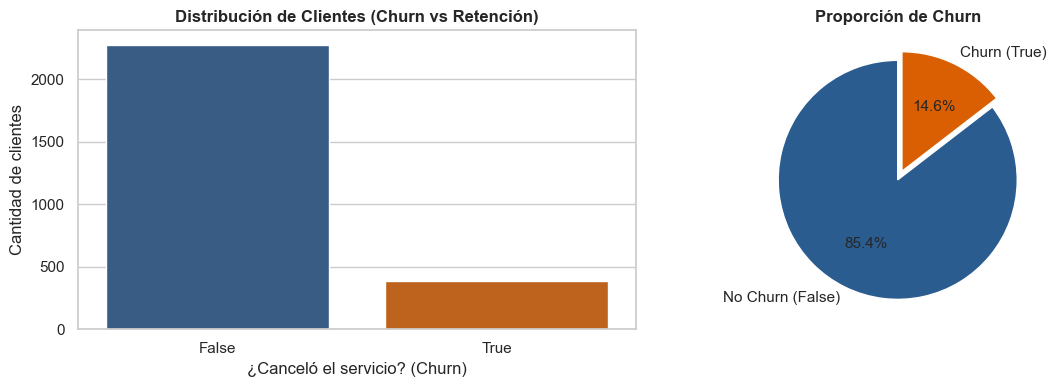

/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1235: RuntimeWarning: invalid value encountered in vecdot
  return np.ve

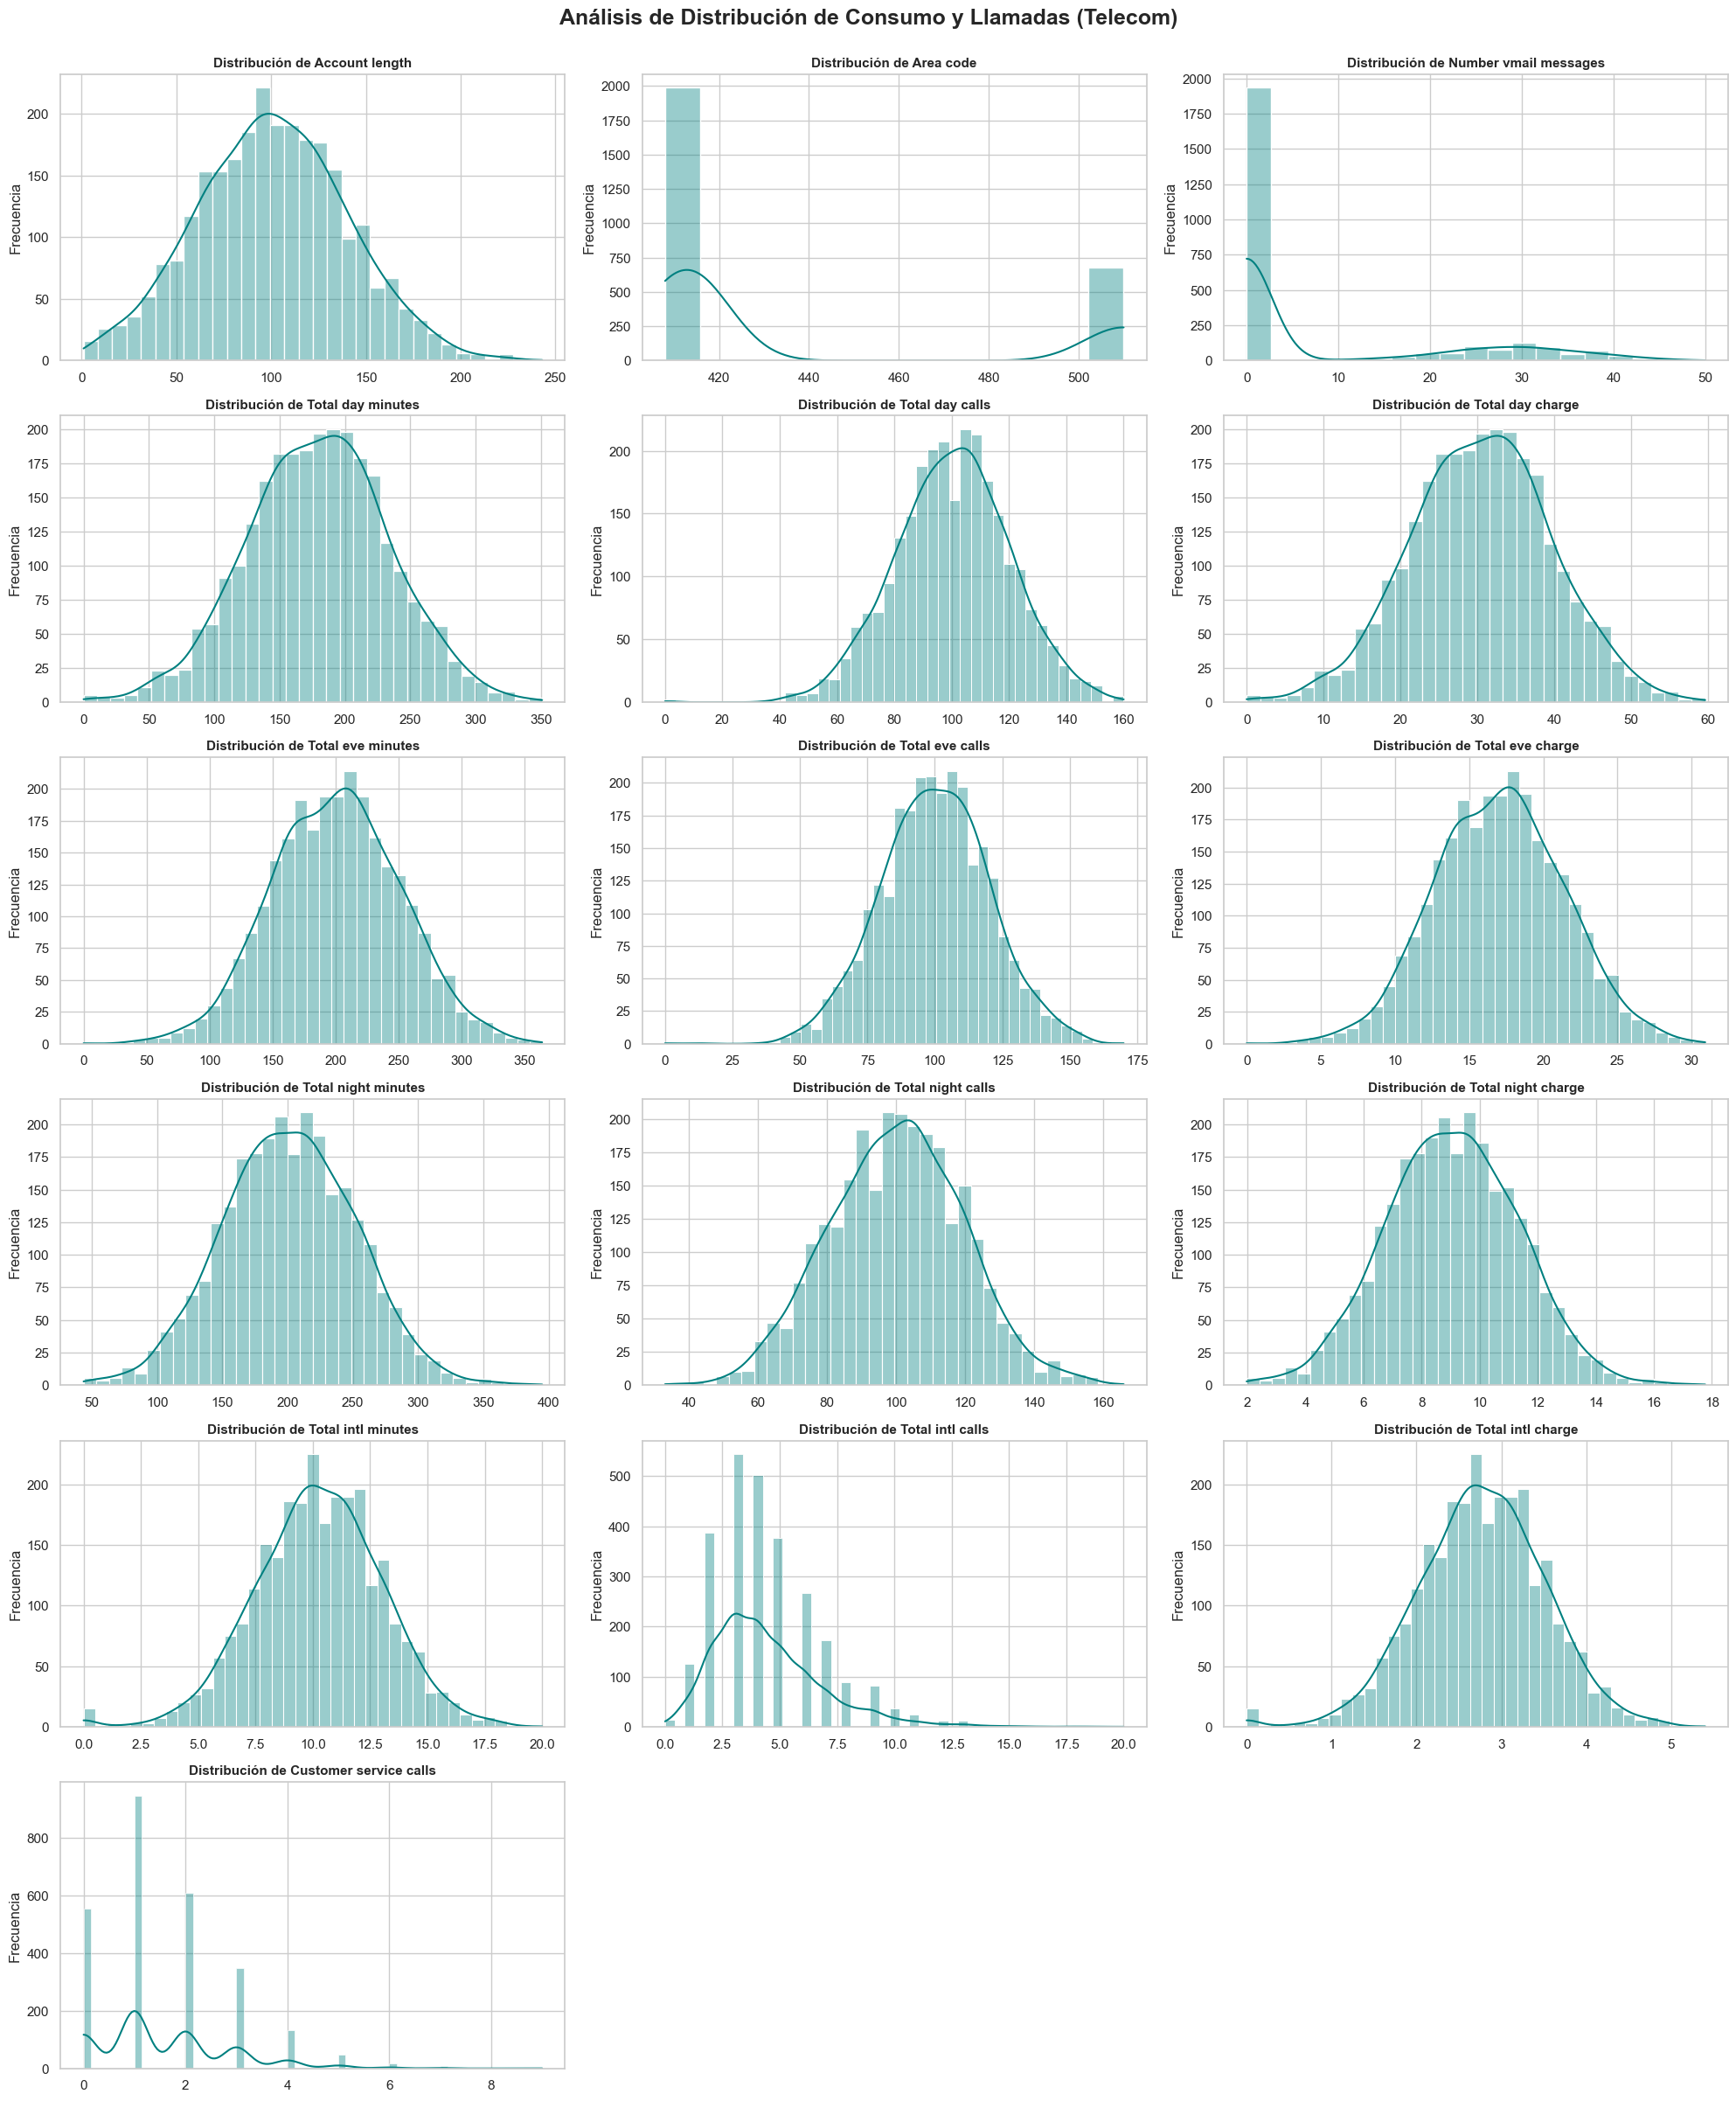

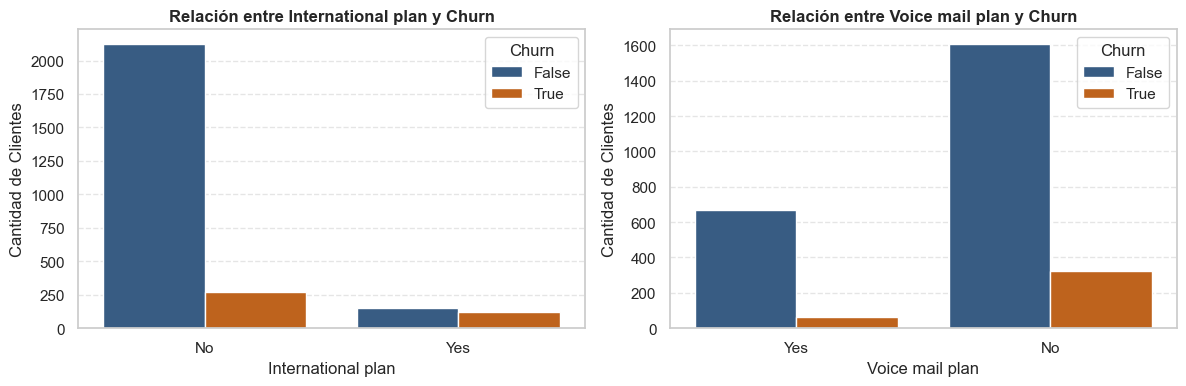

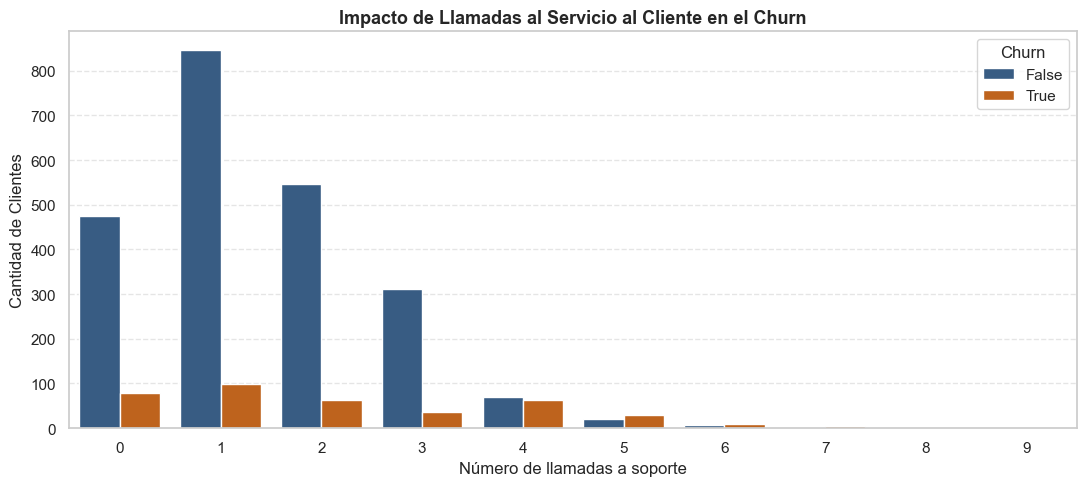

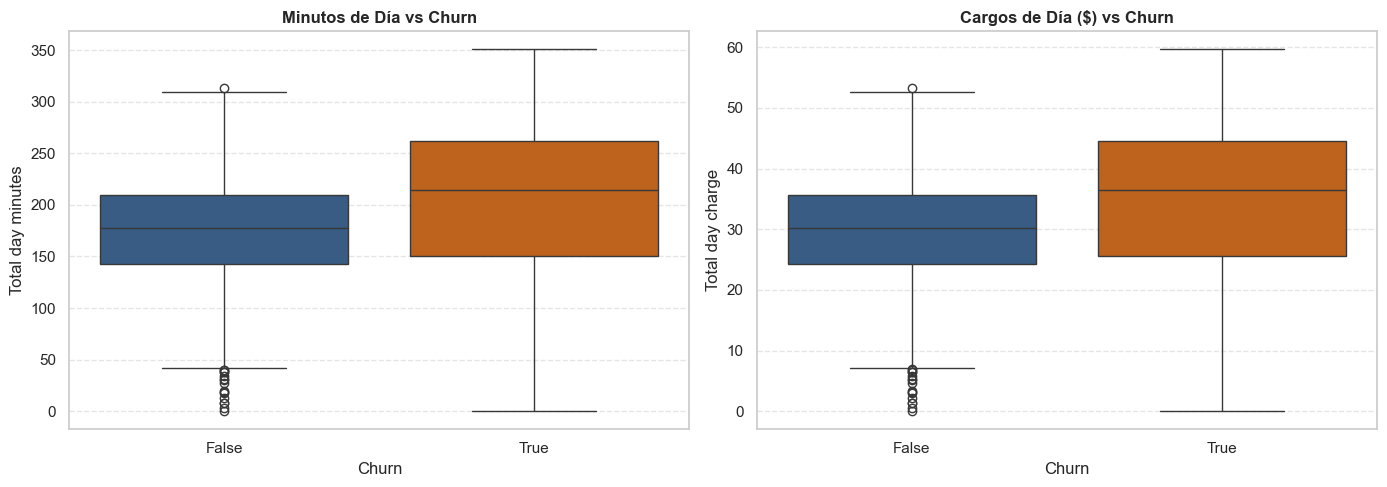

In [173]:
# =========================================================================
# 1. ANÁLISIS DE LA VARIABLE OBJETIVO (CHURN)
# =========================================================================
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Frecuencia absoluta:\n", churn_counts)
print("\nPorcentaje (%):\n", churn_pct.round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
sns.countplot(
    x="Churn",
    data=df,
    ax=ax[0],
    palette=["#2b5c8f", "#d95f02"],
    hue="Churn",
    legend=False,
)
ax[0].set_title("Distribución de Clientes (Churn vs Retención)", fontweight="bold")
ax[0].set_xlabel("¿Canceló el servicio? (Churn)")
ax[0].set_ylabel("Cantidad de clientes")

# Gráfico de pastel
ax[1].pie(
    churn_counts,
    labels=["No Churn (False)", "Churn (True)"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2b5c8f", "#d95f02"],
    explode=(0, 0.08),
)
ax[1].set_title("Proporción de Churn", fontweight="bold")
plt.tight_layout()
plt.show()


# =========================================================================
# 2. DISTRIBUCIÓN DE TODAS LAS VARIABLES NUMÉRICAS (HISTOGRAMAS + KDE)
# =========================================================================
# Excluimos booleanos o Churn si se detectaran como numéricos
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
if "Churn" in num_cols:
    num_cols.remove("Churn")

n_num = len(num_cols)
if n_num > 0:
    n_cols = 3
    rows_n = int(np.ceil(n_num / n_cols))

    fig, axes = plt.subplots(rows_n, n_cols, figsize=(20, rows_n * 4))
    axes = np.array(axes).reshape(-1)

    for i, var in enumerate(num_cols):
        ax = axes[i]
        sns.histplot(df[var].dropna(), kde=True, color="teal", alpha=0.4, ax=ax)
        ax.set_title(f"Distribución de {var}", fontsize=11, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Frecuencia")

    for j in range(n_num, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        "Análisis de Distribución de Consumo y Llamadas (Telecom)",
        fontsize=18,
        fontweight="bold",
        y=1.00,
    )
    plt.tight_layout()
    plt.show()

# Validación de variables ordinales para churn-bigml-80.csv:
# El dataset Telecom Churn no cuenta con escalas de calificación o jerarquías cualitativas
# ordenadas (Likert 1-5). Las variables numéricas son de consumo continuo (minutos, cargos)
# y conteos discretos (llamadas, mensajes), mientras que las cualitativas ('State',
# 'International plan', 'Voice mail plan', 'Area code') son nominales/binarias.


# =========================================================================
# 3. VARIABLES CATEGÓRICAS Y PLANES (INTERNATIONAL PLAN, VOICE MAIL PLAN)
# =========================================================================
plan_cols = [c for c in ["International plan", "Voice mail plan"] if c in df.columns]

if len(plan_cols) > 0:
    fig, axes = plt.subplots(1, len(plan_cols), figsize=(12, 4))
    if len(plan_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, plan_cols):
        sns.countplot(
            data=df,
            x=col,
            hue="Churn",
            palette=["#2b5c8f", "#d95f02"],
            ax=ax,
        )
        ax.set_title(f"Relación entre {col} y Churn", fontweight="bold")
        ax.set_xlabel(col)
        ax.set_ylabel("Cantidad de Clientes")
        ax.grid(axis="y", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


# =========================================================================
# 4. PREDICTORES CLAVE DE CHURN (ATENCIÓN A CLIENTES Y CARGOS POR MINUTO)
# =========================================================================

# A) Llamadas a Servicio al Cliente vs Churn (Customer service calls)
if "Customer service calls" in df.columns:
    plt.figure(figsize=(11, 5))
    sns.countplot(
        data=df,
        x="Customer service calls",
        hue="Churn",
        palette=["#2b5c8f", "#d95f02"],
    )
    plt.title(
        "Impacto de Llamadas al Servicio al Cliente en el Churn",
        fontsize=13,
        fontweight="bold",
    )
    plt.xlabel("Número de llamadas a soporte")
    plt.ylabel("Cantidad de Clientes")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# B) Comparativa de Consumo: Total day minutes y Total day charge vs Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "Total day minutes" in df.columns:
    sns.boxplot(
        data=df,
        x="Churn",
        y="Total day minutes",
        palette=["#2b5c8f", "#d95f02"],
        hue="Churn",
        legend=False,
        ax=axes[0],
    )
    axes[0].set_title("Minutos de Día vs Churn", fontweight="bold")
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

if "Total day charge" in df.columns:
    sns.boxplot(
        data=df,
        x="Churn",
        y="Total day charge",
        palette=["#2b5c8f", "#d95f02"],
        hue="Churn",
        legend=False,
        ax=axes[1],
    )
    axes[1].set_title("Cargos de Día ($) vs Churn", fontweight="bold")
    axes[1].grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

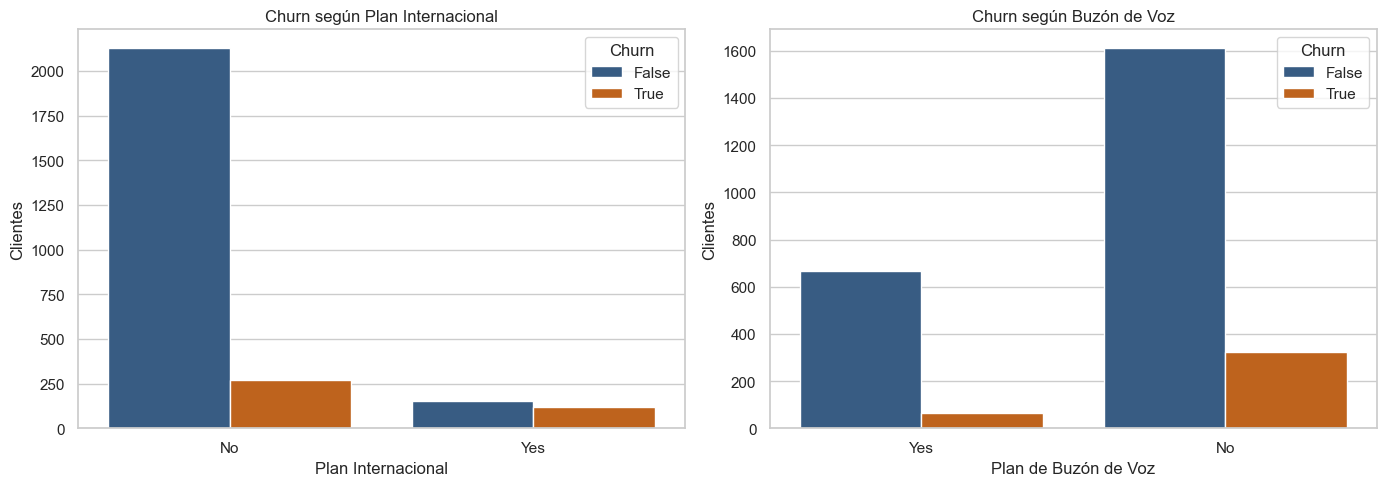

Tasa de Churn por International Plan:


Churn,False,True
International plan,,
No,88.731219,11.268781
Yes,56.296296,43.703704



Tasa de Churn por Voice Mail Plan:


Churn,False,True
Voice mail plan,,
No,83.290222,16.709778
Yes,91.132333,8.867667


In [174]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa de churn por plan internacional
sns.countplot(
    x="International plan",
    hue="Churn",
    data=df,
    ax=axes[0],
    palette=["#2b5c8f", "#d95f02"],
)
axes[0].set_title("Churn según Plan Internacional")
axes[0].set_xlabel("Plan Internacional")
axes[0].set_ylabel("Clientes")

# Tasa de churn por plan de buzón de voz
sns.countplot(
    x="Voice mail plan",
    hue="Churn",
    data=df,
    ax=axes[1],
    palette=["#2b5c8f", "#d95f02"],
)
axes[1].set_title("Churn según Buzón de Voz")
axes[1].set_xlabel("Plan de Buzón de Voz")
axes[1].set_ylabel("Clientes")

plt.tight_layout()
plt.show()

# Tablas cruzadas con porcentajes relativos
print("Tasa de Churn por International Plan:")
display(pd.crosstab(df["International plan"], df["Churn"], normalize="index") * 100)

print("\nTasa de Churn por Voice Mail Plan:")
display(pd.crosstab(df["Voice mail plan"], df["Churn"], normalize="index") * 100)

/var/folders/5r/b7wcl2fn4632p_4rwztzn0740000gn/T/ipykernel_16240/1701656696.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


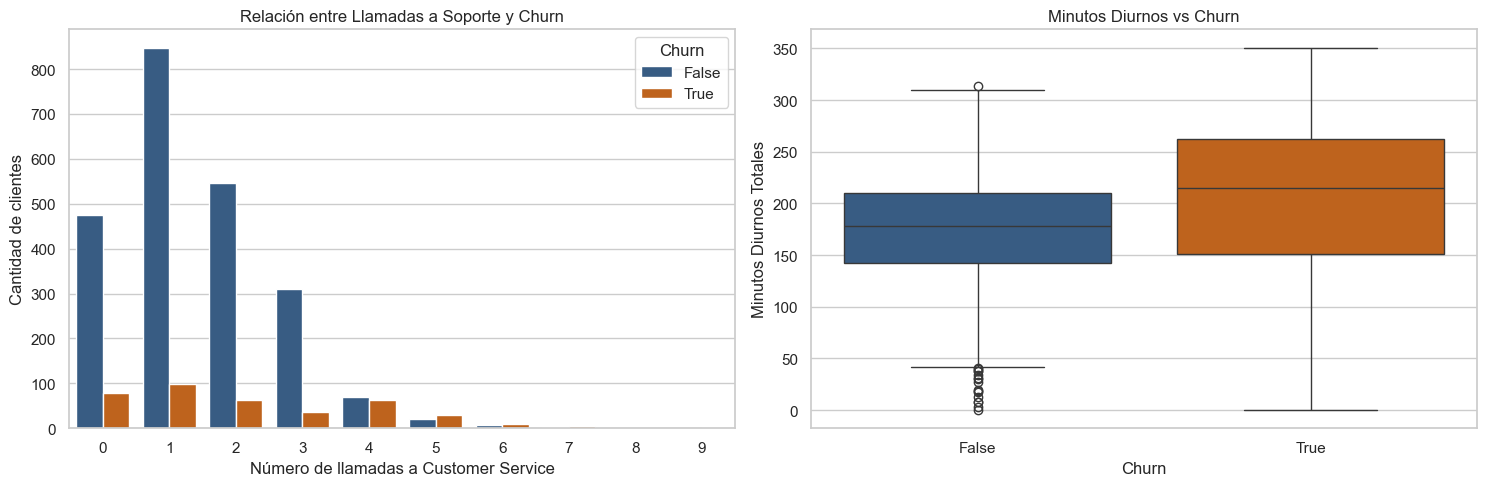

In [175]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Llamadas a servicio al cliente vs Churn
sns.countplot(
    x="Customer service calls",
    hue="Churn",
    data=df,
    ax=axes[0],
    palette=["#2b5c8f", "#d95f02"],
)
axes[0].set_title("Relación entre Llamadas a Soporte y Churn")
axes[0].set_xlabel("Número de llamadas a Customer Service")
axes[0].set_ylabel("Cantidad de clientes")

# 2. Distribución de Minutos Diurnos según Churn
sns.boxplot(
    x="Churn",
    y="Total day minutes",
    data=df,
    ax=axes[1],
    palette=["#2b5c8f", "#d95f02"],
)
axes[1].set_title("Minutos Diurnos vs Churn")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Minutos Diurnos Totales")

plt.tight_layout()
plt.show()

**Paso 3: Limpia los datos:**

Identifica y trata valores faltantes, duplicados, outliers y tipos incorrectos.
Documenta cada decisión que tomes.

In [176]:
# Creamos una copia explícita de trabajo para mantener la integridad de los datos crudos
df_clean = df.copy()

print(f"Dimensiones iniciales: {df_clean.shape}")

Dimensiones iniciales: (2666, 20)


In [177]:
# Comprobación de nulos por columna
missing_summary = df_clean.isnull().sum()
print("Valores nulos por variable:")
print(missing_summary[missing_summary > 0])

Valores nulos por variable:
Series([], dtype: int64)


In [178]:
# Búsqueda de filas íntegramente duplicadas
num_duplicates = df_clean.duplicated().sum()
print(f"Número de filas duplicadas: {num_duplicates}")

if num_duplicates > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print("Duplicados eliminados exitosamente.")

Número de filas duplicadas: 0


In [179]:
# 1. Area code: Representa una zona telefónica (categórica), no una magnitud matemática
df_clean["Area code"] = df_clean["Area code"].astype(str)

# 2. Variables binarias de texto: Mapeo a valores numéricos (1/0)
binary_map = {"Yes": 1, "No": 0, "yes": 1, "no": 0}
df_clean["International plan"] = df_clean["International plan"].map(binary_map)
df_clean["Voice mail plan"] = df_clean["Voice mail plan"].map(binary_map)

# 3. Variable objetivo Churn: Mapeo de booleano a binario (True -> 1, False -> 0)
df_clean["Churn"] = df_clean["Churn"].astype(int)

# Verificación de tipos resultantes
print("Tipos de datos tras la conversión:")
print(
    df_clean[
        ["Area code", "International plan", "Voice mail plan", "Churn"]
    ].dtypes
)

Tipos de datos tras la conversión:
Area code             object
International plan     int64
Voice mail plan        int64
Churn                  int64
dtype: object


In [180]:
# Inspección de valores extremos mediante IQR en variables de consumo continuo
continuous_cols = [
    "Total day minutes",
    "Total eve minutes",
    "Total night minutes",
    "Total intl minutes",
    "Customer service calls",
]

outlier_report = {}
for col in continuous_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = (
        (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    ).sum()
    outlier_report[col] = {
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "Límite Inferior": round(lower_bound, 2),
        "Límite Superior": round(upper_bound, 2),
        "Outliers": outliers,
        "% Outliers": round((outliers / len(df_clean)) * 100, 2),
    }

pd.DataFrame(outlier_report).T

,Q1,Q3,Límite Inferior,Límite Superior,Outliers,% Outliers
Total day minutes,143.40,215.90,34.65,324.65,21.0,0.79
Total eve minutes,165.30,235.10,60.60,339.80,17.0,0.64
Total night minutes,166.92,236.48,62.60,340.80,22.0,0.83
Total intl minutes,8.50,12.10,3.10,17.50,37.0,1.39
Customer service calls,1.00,2.00,-0.50,3.50,210.0,7.88


In [181]:
# =========================================================================
# Eliminación de columnas redundantes por multicolinealidad perfecta (r = 1.00)
# =========================================================================
cols_redundantes = [
    "Total day charge",
    "Total eve charge",
    "Total night charge",
    "Total intl charge",
]

# Eliminamos solo las que existan en el DataFrame
df_clean.drop(columns=cols_redundantes, inplace=True, errors="ignore")

#########################################################################
# JUSTIFICACIÓN TÉCNICA:
# - Total day charge, Total eve charge, Total night charge, Total intl charge:
#   Presentan correlación de 1.00 con sus respectivos 'minutes'. Son una
#   transformación lineal exacta (tarifa constante por minuto). Eliminar
#   los cargos previene problemas de multicolinealidad en modelos lineales,
#   regresiones logísticas y algoritmos basados en distancias (KNN, SVM).
# - Nota: Si tu pipeline no maneja alta cardinalidad en variables nominales,
#   'State' (51 categorías) también podría removerse o codificarse.
#########################################################################

# ++++++++++ Termina sección para agregar código +++++++++++++++++++++++++++

# Verifiquemos de qué tamaño queda el DataFrame:
print("Tamaño del nuevo DataFrame:", df_clean.shape)
print("Columnas restantes:", df_clean.columns.tolist())

Tamaño del nuevo DataFrame: (2666, 16)
Columnas restantes: ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls', 'Churn']


**Paso 4: Entrena un modelo base:**

Selecciona un modelo sencillo (baseline) apropiado para el problema.
Divide los datos en entrenamiento y prueba, y entrénalo.

In [182]:
#Iniciamos la configuracion de mlflow
mlflow.set_tracking_uri("https://tasha-interlinear-berneice.ngrok-free.dev")
mlflow.set_experiment("Churn_Test_Telco_v1")

<Experiment: artifact_location='mlflow-artifacts:/2', creation_time=1790899051476, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1790899051476, lifecycle_stage='active', name='Churn_Test_Telco_v1', tags={}, trace_location=None, workspace='default'>

=== Distribución de las Particiones ===
Muestras Train: 1866 | Tasa Churn: 0.1458
Muestras Val:   400 | Tasa Churn: 0.1450
Muestras Test:  400 | Tasa Churn: 0.1450



/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:333: RuntimeWarning: overflow encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_streng

¡Pipeline baseline entrenado con éxito!
Umbral óptimo seleccionado en Val: 0.6800 (F1 Val: 0.6333)

=== Reporte de Clasificación en Test (con Umbral Óptimo) ===
              precision    recall  f1-score   support

    No Churn       0.89      0.85      0.87       342
       Churn       0.32      0.40      0.35        58

    accuracy                           0.79       400
   macro avg       0.60      0.63      0.61       400
weighted avg       0.81      0.79      0.80       400



/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,Métrica,Puntaje
0,test_roc_auc,0.7228
1,test_pr_auc,0.3069
2,test_recall,0.3966
3,test_precision,0.3151
4,test_f1_score,0.3511


/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


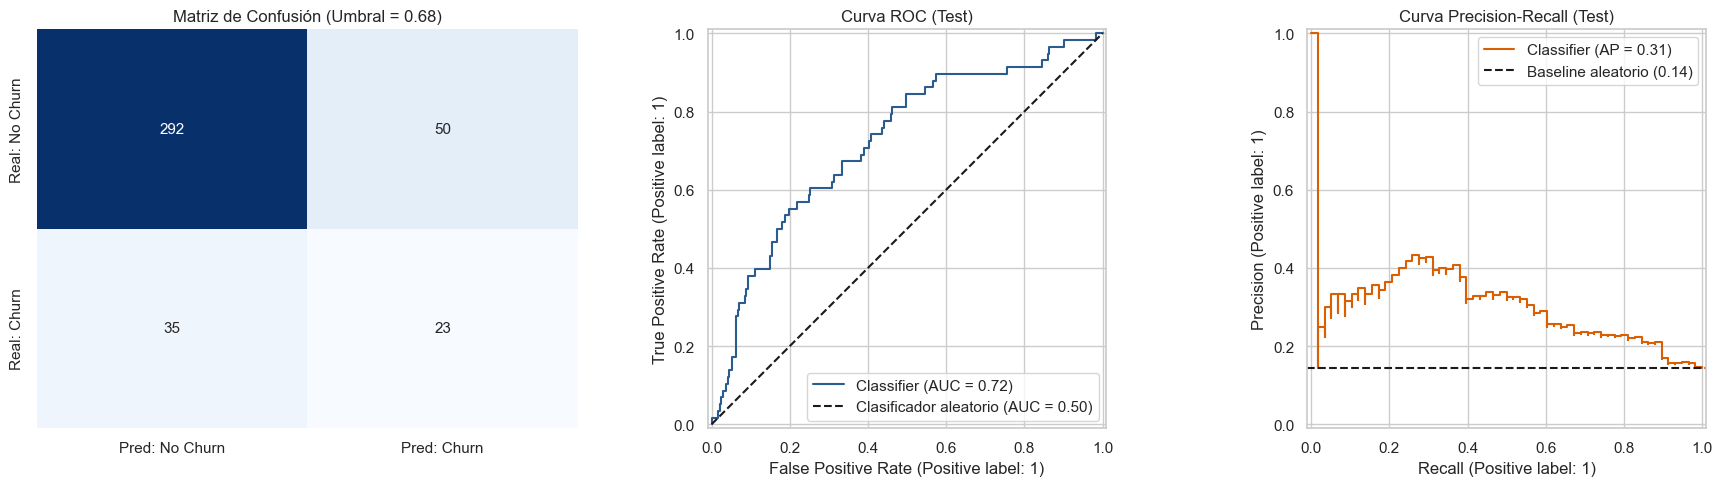

/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (floa


RUN ID registrado en MLflow: 09ecf05e36ea4a2e886576582a92e090
🏃 View run industrious-frog-391 at: https://tasha-interlinear-berneice.ngrok-free.dev/#/experiments/2/runs/09ecf05e36ea4a2e886576582a92e090
🧪 View experiment at: https://tasha-interlinear-berneice.ngrok-free.dev/#/experiments/2


In [183]:
# ==============================================================================
# 1. SEPARACIÓN DE VARIABLES (X, y)
# ==============================================================================
# Excluimos 'Churn' (target) y 'State' (para la línea base inicial)
X = df_clean.drop(columns=["Churn", "State"])
y = df_clean["Churn"]

# ==============================================================================
# 2. PARTICIÓN ESTRATIFICADA EN 3 VÍAS (70% Train, 15% Val, 15% Test)
# ==============================================================================
# Paso A: Extraer 15% para el conjunto ciego de Test final
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Paso B: Extraer 15% del total original para Validación (15 / 85 ≈ 0.1765)
val_ratio = 0.15 / (1.0 - 0.15)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio, random_state=42, stratify=y_temp
)

print("=== Distribución de las Particiones ===")
print(f"Muestras Train: {X_train.shape[0]} | Tasa Churn: {y_train.mean():.4f}")
print(f"Muestras Val:   {X_val.shape[0]} | Tasa Churn: {y_val.mean():.4f}")
print(f"Muestras Test:  {X_test.shape[0]} | Tasa Churn: {y_test.mean():.4f}\n")

# ==============================================================================
# 3. DEFINICIÓN DEL PREPROCESADOR (ColumnTransformer)
# ==============================================================================
categorical_features = ["Area code"]
binary_features = ["International plan", "Voice mail plan"]
numeric_features = [
    col
    for col in X.columns
    if col not in categorical_features + binary_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features,
        ),
        ("bin", "passthrough", binary_features),
    ]
)

# Benchmark Dummy (ajustado de referencia únicamente sobre Train)
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

# ==============================================================================
# 4. CONFIGURACIÓN Y EXPERIMENTACIÓN CON MLFLOW
# ==============================================================================
mlflow.set_tracking_uri("https://tasha-interlinear-berneice.ngrok-free.dev")
mlflow.set_experiment("Churn_Test_Telco_v1")

with mlflow.start_run() as run:
    # --- Parámetros de Configuración ---
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("class_weight", "balanced")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("max_iter", 1000)
    mlflow.log_param("train_split_pct", 0.70)
    mlflow.log_param("val_split_pct", 0.15)
    mlflow.log_param("test_split_pct", 0.15)

    # --- Construcción del Pipeline ---
    baseline_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    class_weight="balanced", random_state=42, max_iter=1000
                ),
            ),
        ]
    )

    # Ajuste exclusivo sobre Train (aprende scalers y pesos sin leakage)
    baseline_pipeline.fit(X_train, y_train)
    print("¡Pipeline baseline entrenado con éxito!")

    # --- Optimización del Umbral de Decisión en Validación ---
    y_val_proba = baseline_pipeline.predict_proba(X_val)[:, 1]

    thresholds = np.linspace(0.1, 0.9, 81)
    f1_scores = [f1_score(y_val, y_val_proba >= th) for th in thresholds]
    best_idx = int(np.argmax(f1_scores))
    best_threshold = float(thresholds[best_idx])
    best_val_f1 = float(f1_scores[best_idx])

    mlflow.log_param("optimal_threshold", round(best_threshold, 4))
    mlflow.log_metric("val_best_f1_score", best_val_f1)
    print(
        f"Umbral óptimo seleccionado en Val: {best_threshold:.4f} (F1 Val: {best_val_f1:.4f})"
    )

    # --- Evaluación Final Ciega en Test ---
    y_test_proba = baseline_pipeline.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= best_threshold).astype(int)

    test_metrics = {
        "test_roc_auc": float(roc_auc_score(y_test, y_test_proba)),
        "test_pr_auc": float(average_precision_score(y_test, y_test_proba)),
        "test_recall": float(recall_score(y_test, y_test_pred)),
        "test_precision": float(precision_score(y_test, y_test_pred)),
        "test_f1_score": float(f1_score(y_test, y_test_pred)),
    }
    mlflow.log_metrics(test_metrics)

    print("\n=== Reporte de Clasificación en Test (con Umbral Óptimo) ===")
    print(
        classification_report(
            y_test, y_test_pred, target_names=["No Churn", "Churn"]
        )
    )

    metrics_df = pd.DataFrame(
        list(test_metrics.items()), columns=["Métrica", "Puntaje"]
    )
    display(metrics_df.round(4))

    # ==========================================================================
    # 5. GENERACIÓN Y REGISTRO DE ARTEFACTOS
    # ==========================================================================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Matriz de Confusión
    cm = confusion_matrix(y_test, y_test_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[0],
        xticklabels=["Pred: No Churn", "Pred: Churn"],
        yticklabels=["Real: No Churn", "Real: Churn"],
    )
    axes[0].set_title(f"Matriz de Confusión (Umbral = {best_threshold:.2f})")

    # Curva ROC
    RocCurveDisplay.from_predictions(
        y_test, y_test_proba, ax=axes[1], color="#2b5c8f"
    )
    axes[1].plot(
        [0, 1], [0, 1], "k--", label="Clasificador aleatorio (AUC = 0.50)"
    )
    axes[1].set_title("Curva ROC (Test)")
    axes[1].legend()

    # Curva Precision-Recall
    PrecisionRecallDisplay.from_predictions(
        y_test, y_test_proba, ax=axes[2], color="#d95f02"
    )
    axes[2].axhline(
        y=y_test.mean(),
        color="k",
        linestyle="--",
        label=f"Baseline aleatorio ({y_test.mean():.2f})",
    )
    axes[2].set_title("Curva Precision-Recall (Test)")
    axes[2].legend()

    plt.tight_layout()

    # Guardar y subir visualizaciones
    plot_file = "model_evaluation_plots.png"
    fig.savefig(plot_file, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    mlflow.log_artifact(plot_file, artifact_path="evaluation_plots")
    if os.path.exists(plot_file):
        os.remove(plot_file)

    # Subir notas del experimento asegurando el directorio destino
    notes_file = "Semana3/run_notes.txt"
    os.makedirs(os.path.dirname(notes_file), exist_ok=True)
    with open(notes_file, "w", encoding="utf-8") as f:
        f.write("Entrenamiento baseline completado exitosamente.\n")
        f.write(f"Umbral óptimo seleccionado en validación: {best_threshold:.4f}\n")
        f.write(f"F1 en Test con dicho umbral: {test_metrics['test_f1_score']:.4f}\n")

    mlflow.log_artifact(notes_file, artifact_path="metadata")

    # --- Registro del Pipeline de punta a punta en MLflow ---
    signature = infer_signature(X_val, baseline_pipeline.predict(X_val))
    mlflow.sklearn.log_model(
        sk_model=baseline_pipeline,
        artifact_path="model",
        signature=signature,
        input_example=X_val.iloc[:5],
    )

    print(f"\nRUN ID registrado en MLflow: {run.info.run_id}")

**Paso 5: Evalúa el modelo:**

Calcula al menos una métrica de desempeño coherente con el tipo de problema.
Interpreta el resultado de manera detallada.

/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,Métrica,Puntaje
0,ROC-AUC,0.7228
1,PR-AUC (Average Precision),0.3069
2,Recall (Sensibilidad),0.6034
3,Precision,0.2846
4,F1-Score,0.3867


/Users/lsanchez/miniconda3/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


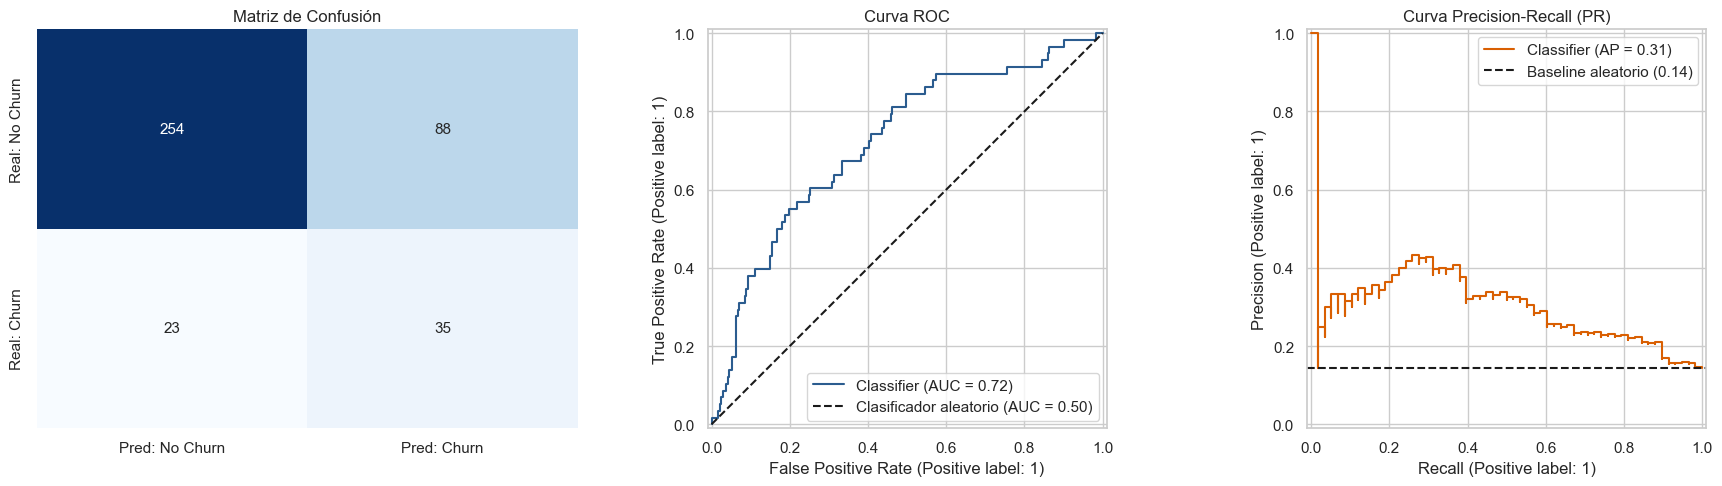

In [184]:
# 1. Predicciones probabilísticas y de clase
y_pred = baseline_pipeline.predict(X_test)
y_pred_proba = baseline_pipeline.predict_proba(X_test)[:, 1]

# 2. Métricas globales focalizadas en la clase positiva (Churn = 1)
metrics = {
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
    "PR-AUC (Average Precision)": average_precision_score(y_test, y_pred_proba),
    "Recall (Sensibilidad)": recall_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
}

metrics_df = pd.DataFrame(
    list(metrics.items()), columns=["Métrica", "Puntaje"]
)
display(metrics_df.round(4))

# 3. Visualización: Matriz de Confusión y Curvas ROC / Precision-Recall
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matriz de confusión con porcentajes y totales
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0],
    xticklabels=["Pred: No Churn", "Pred: Churn"],
    yticklabels=["Real: No Churn", "Real: Churn"],
)
axes[0].set_title("Matriz de Confusión")

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], color="#2b5c8f")
axes[1].plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio (AUC = 0.50)")
axes[1].set_title("Curva ROC")
axes[1].legend()

# Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_proba, ax=axes[2], color="#d95f02"
)
axes[2].axhline(
    y=y_test.mean(),
    color="k",
    linestyle="--",
    label=f"Baseline aleatorio ({y_test.mean():.2f})",
)
axes[2].set_title("Curva Precision-Recall (PR)")
axes[2].legend()

plt.tight_layout()
plt.show()

**Paso 6: Registra el experimento en MLFlow:**

Usa MLFlow Tracking para registrar parámetros y métricas.
Solo si aplica, registra los artefactos del modelo base.

**Paso 7: Redacta una reflexión:**

Al final del notebook, explica brevemente qué mejorarías en este flujo aplicando prácticas de MLOps y por qué.
¿Cómo se ven reflejados estos aprendizajes dentro de tu área profesional?
150 palabras o más de extensión.